In [ ]:
import json, re
from itertools import product

import numpy as np
import nltk, spacy
from nltk import pos_tag
from nltk.tokenize import TreebankWordTokenizer
from nltk.tokenize.punkt import PunktTokenizer
from sentence_transformers import SentenceTransformer
from tqdm import tqdm

nltk.download("punkt_tab", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)

SEED_PATH = "seed_dict.json"
TAUS = [0.40, 0.50, 0.55, 0.60, 0.65, 0.70]   # soglia minima di similarità
MARGIN = 0.02  # distanza minima tra 1a e 2a categoria

## Scarico dataset `TAB` (Text Anonymization Benchmark)


In [ ]:
import os

if not os.path.exists("echr_train.json"):
    !wget -q https://raw.githubusercontent.com/NorskRegnesentral/text-anonymization-benchmark/master/echr_train.json

## 1. Centroidi delle categorie

In [ ]:
seed_dict = json.load(open(SEED_PATH, encoding="utf-8"))
model = SentenceTransformer("all-mpnet-base-v2")

# Un centroide per categoria: media degli embedding dei termini seed, poi rinormalizzata a norma 1
category_names = sorted(seed_dict)
centroids = np.stack([
    model.encode([t.lower() for t in seed_dict[c]], normalize_embeddings=True).mean(0)
    for c in category_names
])

centroids /= np.linalg.norm(centroids, axis=1, keepdims=True)
print(centroids.shape, category_names)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:121: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

(7, 768) ['education', 'location', 'nationality', 'occupation', 'political_role', 'religion', 'temporal']


## 2. Candidati: nomi (spaCy) esclusi, n-grammi con pattern POS

In [ ]:
!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 14.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
nlp = spacy.load("en_core_web_md", disable=["parser", "lemmatizer"])

# Restituisce gli offset (start, end) delle entità PERSON trovate da spaCy, da escludere dai candidati
def person_spans(txt: str) -> list[tuple[int, int]]:
    return [(e.start_char, e.end_char) for e in nlp(txt).ents if e.label_ == "PERSON"]

_TOK, _SENT = TreebankWordTokenizer(), PunktTokenizer("english")

NOUN = ("NN", "NNS", "NNP", "NNPS")
_SHAPES = [("JJ", "N"), ("N", "N"), ("N", "CD"), ("CD", "JJ"), ("CD", "N"), ("CD", "N", "CD"),
           ("CD", "N", "JJ"), ("JJ", "JJ", "N"), ("JJ", "N", "N"), ("N", "N", "N"), ("N", "IN", "N")]
VALID_POS = {p for s in _SHAPES for p in product(*[NOUN if t == "N" else (t,) for t in s])}
UNIGRAM_OK = {"NN", "NNS", "NNP", "NNPS", "CD", "JJ"}
BAD_MIDDLE = {"CC", "DT", "WP", "WRB", "MD", "VBD", "VBZ", "VBP", "VBN", "VBG", "TO", "RP"}

# Dice se una sequenza di tag POS è un pattern di n-gram ammesso (unigram o forma in VALID_POS)
def is_valid_ngram(pos: tuple[str, ...]) -> bool:
    if len(pos) == 1:
        return pos[0] in UNIGRAM_OK
    return not any(t in BAD_MIDDLE for t in pos[1:-1]) and pos in VALID_POS

# Divide il testo in gruppi di parole consecutive con tag POS e offset, spezzando sulla punteggiatura
def segments(txt: str) -> list[list[tuple]]:
    spans = [(s + a, s + b) for s, e in _SENT.span_tokenize(txt) for a, b in _TOK.span_tokenize(txt[s:e])]
    groups, cur = [], []
    for (w, tag), (a, b) in zip(pos_tag([txt[a:b] for a, b in spans]), spans):
        if any(c.isalnum() for c in w):
            cur.append((w, tag, a, b))
        elif cur:
            groups.append(cur); cur = []
    return groups + [cur] if cur else groups

# Genera gli n-grammi candidati (n=1..3) validi per POS, che non toccano nomi di persona, come {(start, end): testo}
def build_ngrams(txt: str, persons: list[tuple[int, int]]) -> dict:
    out = {}
    for g in segments(txt):
        for n in (1, 2, 3):
            for i in range(len(g) - n + 1):
                w = g[i:i + n]
                start, end = w[0][2], w[-1][3]
                phrase = txt[start:end]
                if not is_valid_ngram(tuple(t for _, t, _, _ in w)):
                    continue
                if any(start < pe and ps < end for ps, pe in persons):
                    continue  # interseca un nome
                if n == 1 and (len(phrase) < 3 or (phrase.isdigit() and len(phrase) != 4)):
                    continue  # unigram: almeno 3 caratteri; numeri solo se di 4 cifre (anni)
                out[(start, end)] = phrase
    return out

## 3. Classificazione (cosine similarity) e anonimizzazione

In [ ]:
_cache: dict[str, np.ndarray] = {}

# Calcola gli embedding normalizzati delle frasi, usando una cache per non ricalcolare frasi già viste
def encode(phrases: list[str]) -> np.ndarray:
    new = [p for p in dict.fromkeys(phrases) if p not in _cache]
    if new:
        _cache.update(zip(new, model.encode(new, normalize_embeddings=True, batch_size=256)))
    return np.stack([_cache[p] for p in phrases])

# Assegna a ogni n-gram la categoria col centroide più simile, scartando i casi ambigui (margine < MARGIN)
def classify(ngrams: dict) -> list[dict]:
    if not ngrams:
        return []
    keys = list(ngrams)
    sim = encode([ngrams[k].lower() for k in keys]) @ centroids.T
    top2 = np.sort(sim, axis=1)[:, -2:]
    return [{"start": s, "end": e, "category": category_names[sim[i].argmax()], "score": float(top2[i, 1])}
            for i, (s, e) in enumerate(keys) if top2[i, 1] - top2[i, 0] >= MARGIN]

# Risolve le sovrapposizioni: tra span sovrapposti tiene il più lungo (a parità, quello con score più alto)
def select_spans(spans: list[dict]) -> list[dict]:
    kept = []
    for sp in sorted(spans, key=lambda s: (-(s["end"] - s["start"]), -s["score"])):
        if not any(sp["end"] > o["start"] and sp["start"] < o["end"] for o in kept):
            kept.append(sp)
    return sorted(kept, key=lambda s: s["start"])

# Produce il testo anonimizzato sostituendo ogni span selezionato con [CATEGORIA]
def anonymize(txt: str, spans: list[dict]) -> str:
    out, prev = [], 0
    for sp in select_spans(spans):
        out += [txt[prev:sp["start"]], f"[{sp['category'].upper()}]"]
        prev = sp["end"]
    return "".join(out) + txt[prev:]

## 4. Valutazione su **`TAB`** ([echr_train](https://github.com/NorskRegnesentral/text-anonymization-benchmark/blob/master/echr_train.json))
Confronto a livello di token tra le maschere del sistema e quelle di un annotatore (DIRECT + QUASI).

In [ ]:
tab = json.load(open("echr_train.json", encoding="utf-8"))
TOKEN = re.compile(r"\w+|[^\w\s]")

# Restituisce gli indici dei token del testo che si sovrappongono ad almeno uno degli span dati
def masked_tokens(txt: str, spans: list[tuple[int, int]]) -> set[int]:
    chars = set()
    for s, e in spans:
        chars.update(range(s, e))
    return {i for i, m in enumerate(TOKEN.finditer(txt))
            if any(c in chars for c in range(*m.span()))}

# Calcola Accuracy, Precision, Recall e F1 a livello di token
def run(preds: list[set], gold: list[set], n_tokens: list[int]
        ) -> tuple[float, float, float, float]:
    tp = fp = fn = tn = 0
    for p, g, n in zip(preds, gold, n_tokens):
        tp += len(p & g)
        fp += len(p - g)
        fn += len(g - p)
        tn += n - len(p | g)
    tot = tp + tn + fp + fn
    A = (tp + tn) / tot if tot else 0.0
    P = tp / (tp + fp) if tp + fp else 0.0
    R = tp / (tp + fn) if tp + fn else 0.0
    F = 2 * P * R / (P + R) if P + R else 0.0
    return A, P, R, F

# Restituisce le annotazioni del primo annotatore del documento (uno solo per documento)
def first_annotator(d: dict) -> dict:
    return next(iter(d["annotations"].values()))

# Gold: per ogni documento, token delle menzioni DIRECT/QUASI
gold = [masked_tokens(d["text"], [(m["start_offset"], m["end_offset"])
                                  for m in first_annotator(d)["entity_mentions"]
                                  if m["identifier_type"] in ("DIRECT", "QUASI")])
        for d in tab]
n_tokens = [sum(1 for _ in TOKEN.finditer(d["text"])) for d in tab]
print(f"{len(tab)} documenti, {sum(len(d['annotations']) > 1 for d in tab)} con più di un annotatore")

1014 documenti, 67 con più di un annotatore


In [9]:
persons = [person_spans(d["text"]) for d in tqdm(tab, desc="NER")]
cands = [classify(build_ngrams(d["text"], p)) for d, p in zip(tab, persons)]

print("| Approccio | Accuracy | Precision | Recall | F1 |")

metrics = {}
for tau in TAUS:
    preds = []
    for d, c, p in zip(tab, cands, persons):
        spans = [{"start": a, "end": b, "score": 1.0} for a, b in p]
        kept = select_spans(spans + [s for s in c if s["score"] >= tau])
        preds.append(masked_tokens(d["text"], [(s["start"], s["end"]) for s in kept]))
    A, P, R, F = run(preds, gold, n_tokens)
    metrics[tau] = {"A": A, "P": P, "R": R, "F": F}
    print(f"| Cosine τ={tau:.2f} | {A:.3f} | {P:.3f} | {R:.3f} | {F:.3f} |")

NER: 100%|██████████| 1014/1014 [02:46<00:00,  6.11it/s]


| Approccio | Accuracy | Precision | Recall | F1 |
| Cosine τ=0.40 | 0.861 | 0.424 | 0.723 | 0.535 |
| Cosine τ=0.50 | 0.909 | 0.580 | 0.630 | 0.604 |
| Cosine τ=0.55 | 0.927 | 0.706 | 0.589 | 0.643 |
| Cosine τ=0.60 | 0.925 | 0.756 | 0.470 | 0.580 |
| Cosine τ=0.65 | 0.921 | 0.780 | 0.402 | 0.530 |
| Cosine τ=0.70 | 0.910 | 0.764 | 0.277 | 0.407 |


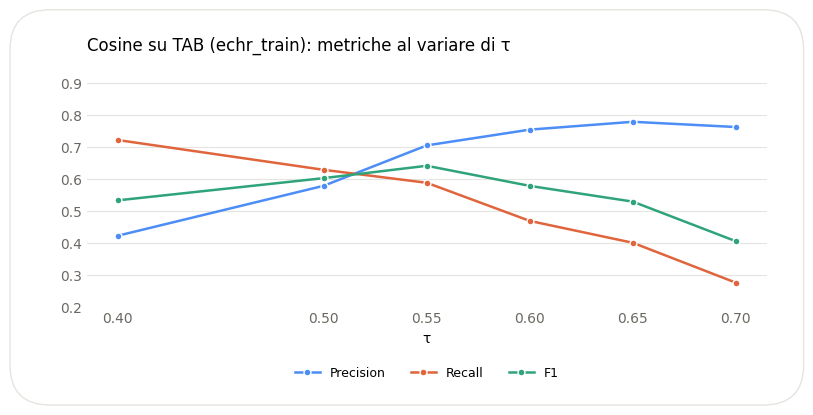

In [14]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

SERIES = [("P", "Precision", "#4c8df6", "-"), ("R", "Recall", "#e0643c", "-"), ("F", "F1", "#2fa37a", "-")]

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_alpha(0)
fig.patches.append(FancyBboxPatch((0.004, 0.006), 0.992, 0.988, transform=fig.transFigure, zorder=-1,
                   boxstyle="round,pad=0,rounding_size=0.05", mutation_aspect=2, fc="white", ec="#e6e4df"))
for k, lab, col, ls in SERIES:
    ax.plot(TAUS, [metrics[t][k] for t in TAUS], ls, color=col, lw=1.8, marker="o", ms=5, mec="white", label=lab)

ax.set(facecolor="none", xticks=TAUS, xlabel="τ", ylim=(0.2, 0.95))
ax.set_title("Cosine su TAB (echr_train): metriche al variare di τ", loc="left", pad=12)
ax.grid(axis="y", color="#e6e4df")
ax.tick_params(length=0, colors="#6b6862")
ax.spines[:].set_visible(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=5, frameon=False, fontsize=9)

fig.subplots_adjust(left=0.10, right=0.95, top=0.85, bottom=0.25)
plt.savefig("tab_tau_sweep.png", dpi=800)
plt.show()